## 5.4 YOLOv8n-seg — Segmentation sémantique BridgeGuard

Ce notebook présente l'entraînement du modèle de segmentation sémantique
YOLOv8n-seg pour la détection des zones d'eau dans le cadre du projet BridgeGarde.

- **Modèle** : YOLOv8n-seg (nano segmentation)
- **Dataset** : Flood Area Segmentation — 290 images annotées (Kaggle)
- **Objectif** : Segmenter pixel par pixel les zones d'eau pour prédire le risque d'inondation
- **Plateforme** : Kaggle GPU Tesla T4

In [1]:
!pip install ultralytics -q

import torch
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"CUDA : {torch.cuda.is_available()}")
print("✅ Prêt !")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.4 MB/s eta 0:00:00a 0:00:01
GPU : Tesla T4
CUDA : True
✅ Prêt !


## 5.4.1 Dataset — Exploration et visualisation

Le dataset **Flood Area Segmentation** disponible sur Kaggle contient
290 images de zones inondées accompagnées de leurs masques de segmentation.
Chaque masque est une image binaire où :
- **Blanc (255)** = zone d'eau
- **Noir (0)** = fond (background)

On visualise 6 exemples pour vérifier la qualité des annotations
avant de lancer l'entraînement.

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/faizalkarim/flood-area-segmentation/metadata.csv
/kaggle/input/datasets/faizalkarim/flood-area-segmentation/Mask/1017.png
/kaggle/input/datasets/faizalkarim/flood-area-segmentation/Mask/2015.png
/kaggle/input/datasets/faizalkarim/flood-area-segmentation/Mask/1084.png
/kaggle/input/datasets/faizalkarim/flood-area-segmentation/Mask/2021.png
/kaggle/input/datasets/faizalkarim/flood-area-segmentation/Mask/1012.png
/kaggle/input/datasets/faizalkarim/flood-area-segmentation/Image/2008.jpg
/kaggle/input/datasets/faizalkarim/flood-area-segmentation/Image/1075.jpg
/kaggle/input/datasets/faizalkarim/flood-area-segmentation/Image/2029.jpg
/kaggle/input/datasets/faizalkarim/flood-area-segmentation/Image/1031.jpg
/kaggle/input/datasets/faizalkarim/flood-area-segmentation/Image/2021.jpg


On divise le dataset en 3 parties :
- **Train (70%)** : 203 images — pour entraîner le modèle
- **Validation (15%)** : 43 images — pour surveiller l'entraînement
- **Test (15%)** : 44 images — pour évaluer les performances finales

Les masques PNG sont convertis au format d'annotation YOLOv8
via un algorithme d'extraction de contours OpenCV, transformant
chaque masque binaire en polygones normalisés.

In [3]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import shutil

BASE_PATH = "/kaggle/input/datasets/faizalkarim/flood-area-segmentation"
IMG_PATH  = f"{BASE_PATH}/Image"
MASK_PATH = f"{BASE_PATH}/Mask"

# Créer structure dossiers YOLOv8
for split in ["train", "val", "test"]:
    os.makedirs(f"/kaggle/working/dataset/{split}/images", exist_ok=True)
    os.makedirs(f"/kaggle/working/dataset/{split}/labels", exist_ok=True)

# Liste images
images = sorted([f for f in os.listdir(IMG_PATH) if f.endswith(".jpg")])
print(f"Total images : {len(images)}")

# Split 70/15/15
train_imgs, temp_imgs = train_test_split(images, test_size=0.30, random_state=42)
val_imgs,  test_imgs  = train_test_split(temp_imgs, test_size=0.50, random_state=42)

print(f"Train : {len(train_imgs)}")
print(f"Val   : {len(val_imgs)}")
print(f"Test  : {len(test_imgs)}")

Total images : 290
Train : 203
Val   : 43
Test  : 44


 **Conversion masques PNG → annotations YOLOv8****

YOLOv8 requiert un format d'annotation spécifique basé sur des polygones normalisés.
On convertit chaque masque binaire PNG en fichier texte contenant les contours
des zones d'eau, normalisés entre 0 et 1 par rapport aux dimensions de l'image.



In [4]:
def mask_to_yolo(mask_path, img_w, img_h):
    """Convertit un masque binaire en annotation YOLO segmentation"""
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (img_w, img_h))
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(
        binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    annotations = []
    for contour in contours:
        if cv2.contourArea(contour) < 100:
            continue
        contour = contour.reshape(-1, 2)
        # Normaliser entre 0 et 1
        points = []
        for x, y in contour:
            points.append(f"{x/img_w:.6f}")
            points.append(f"{y/img_h:.6f}")
        if len(points) >= 6:
            annotations.append("0 " + " ".join(points))

    return annotations

def process_split(img_list, split_name):
    converted = 0
    skipped   = 0
    for img_name in img_list:
        mask_name = img_name.replace(".jpg", ".png")
        img_path  = f"{IMG_PATH}/{img_name}"
        mask_path = f"{MASK_PATH}/{mask_name}"

        if not os.path.exists(mask_path):
            skipped += 1
            continue

        img    = cv2.imread(img_path)
        h, w   = img.shape[:2]
        annots = mask_to_yolo(mask_path, w, h)

        if not annots:
            skipped += 1
            continue

        # Copier image
        shutil.copy(img_path,
            f"/kaggle/working/dataset/{split_name}/images/{img_name}")

        # Écrire annotation
        label_path = f"/kaggle/working/dataset/{split_name}/labels/{img_name.replace('.jpg', '.txt')}"
        with open(label_path, "w") as f:
            f.write("\n".join(annots))

        converted += 1

    print(f"✅ {split_name}: {converted} convertis, {skipped} ignorés")

process_split(train_imgs, "train")
process_split(val_imgs,   "val")
process_split(test_imgs,  "test")

✅ train: 203 convertis, 0 ignorés
✅ val: 43 convertis, 0 ignorés
✅ test: 44 convertis, 0 ignorés


**Fichier de configuration data.yaml**

Le fichier data.yaml est requis par YOLOv8 pour localiser les données
et définir les classes. Il contient les chemins vers les dossiers
train/val/test ainsi que le nombre de classes (nc=1) et leurs noms.

In [5]:
yaml_content = f"""
path: /kaggle/working/dataset
train: train/images
val: val/images
test: test/images

nc: 1
names: ['water']
"""

with open("/kaggle/working/dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ data.yaml créé !")
print(yaml_content)

✅ data.yaml créé !

path: /kaggle/working/dataset
train: train/images
val: val/images
test: test/images

nc: 1
names: ['water']



## 5.4.2 Entraînement — YOLOv8n-seg avec Transfer Learning

On entraîne YOLOv8n-seg en partant des poids pré-entraînés sur COCO
(Transfer Learning). Le modèle nano (n) a été choisi pour sa légèreté
et sa compatibilité avec le Raspberry Pi 4.

**Hyperparamètres :**
| Paramètre | Valeur |
|---|---|
| Epochs | 50 |
| Batch size | 16 |
| Image size | 640×640 |
| Optimizer | AdamW (auto) |
| Learning rate | 0.01 |
| Patience (early stopping) | 10 |
| Modèle base | yolov8n-seg.pt (COCO) |

In [6]:
from ultralytics import YOLO

model   = YOLO("yolov8n-seg.pt")
results = model.train(
    data    = "/kaggle/working/dataset/data.yaml",
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    device  = "cuda",
    patience= 10,
    name    = "bridgegarde_water_seg",
    plots   = True
)

print("✅ Entraînement terminé !")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, 

## 5.4.3 Résultats — Courbes d'entraînement

On visualise l'évolution de la Loss et des métriques (mAP50, mAP50-95)
pendant les 50 epochs pour vérifier la convergence du modèle.

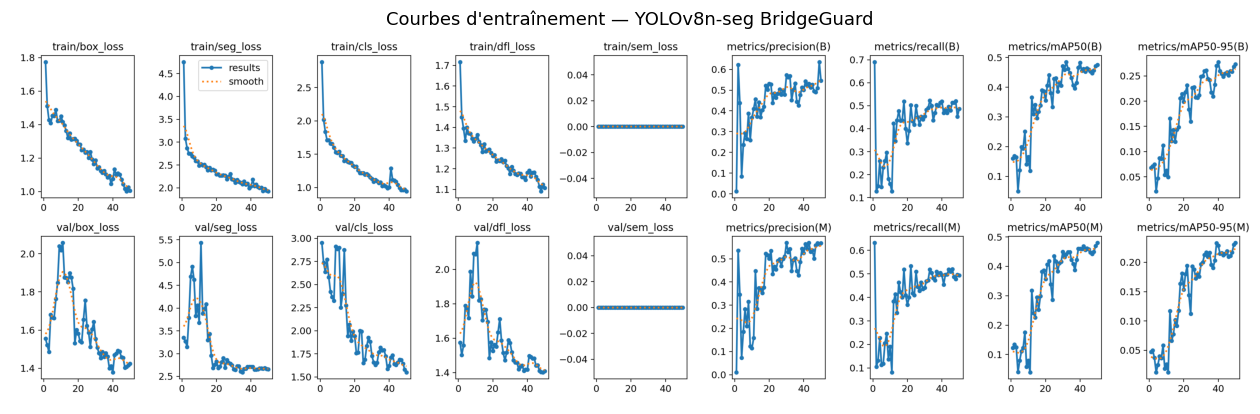

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

results_dir = "/kaggle/working/runs/segment/bridgegarde_water_seg"

img = mpimg.imread(f"{results_dir}/results.png")
plt.figure(figsize=(16, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Courbes d'entraînement — YOLOv8n-seg BridgeGuard", fontsize=13)
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Matrice de confusion****

La matrice de confusion normalisée montre les performances du modèle
par classe. Une valeur élevée sur la diagonale confirme que le modèle
segmente correctement les zones d'eau.

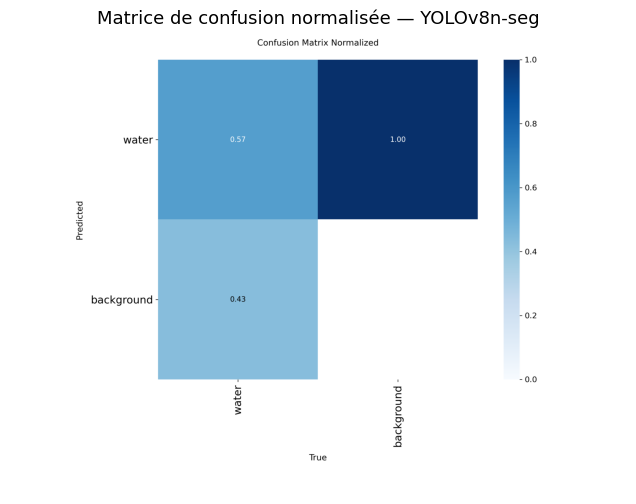

In [9]:
conf = mpimg.imread(f"{results_dir}/confusion_matrix_normalized.png")
plt.figure(figsize=(8, 6))
plt.imshow(conf)
plt.axis("off")
plt.title("Matrice de confusion normalisée — YOLOv8n-seg", fontsize=13)
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Visualisation des prédictions****

On teste le meilleur modèle sur 4 images du jeu de test
pour visualiser qualitativement les performances de segmentation.

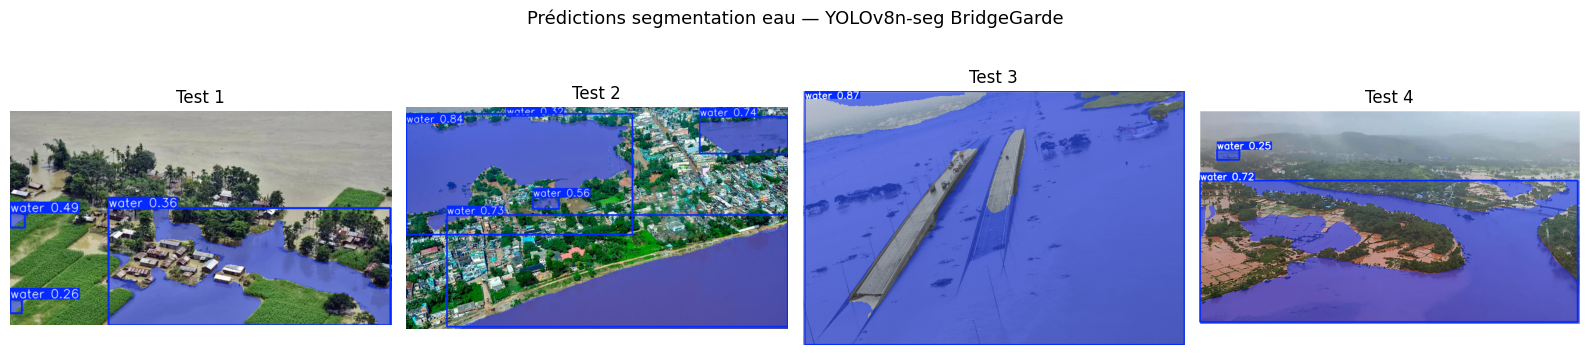

In [10]:
from ultralytics import YOLO
import os

best_model  = YOLO(f"{results_dir}/weights/best.pt")
test_images = sorted(os.listdir("/kaggle/working/dataset/test/images"))[:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Prédictions segmentation eau — YOLOv8n-seg BridgeGarde", fontsize=13)

for idx, img_name in enumerate(test_images):
    img_path = f"/kaggle/working/dataset/test/images/{img_name}"
    result   = best_model.predict(img_path, conf=0.25, verbose=False)[0]
    res_img  = result.plot()
    axes[idx].imshow(res_img[:, :, ::-1])
    axes[idx].set_title(f"Test {idx+1}")
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig("segmentation_results.png", dpi=150, bbox_inches="tight")
plt.show()

**Métriques finales sur jeu de test****

In [11]:
metrics = best_model.val(
    data   = "/kaggle/working/dataset/data.yaml",
    split  = "test",
    verbose= False
)

print("=" * 45)
print("Métriques finales — YOLOv8n-seg BridgeGuard")
print("=" * 45)
print(f"Précision  (P)  : {metrics.seg.p[0]:.3f}")
print(f"Rappel     (R)  : {metrics.seg.r[0]:.3f}")
print(f"mAP50           : {metrics.seg.map50:.3f}")
print(f"mAP50-95        : {metrics.seg.map:.3f}")
print("=" * 45)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2290.1±1069.1 MB/s, size: 554.9 KB)
val: Scanning /kaggle/working/dataset/test/labels... 44 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44 475.9it/s 0.1s
val: New cache created: /kaggle/working/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1it/s 2.8s1.6s
                   all         44        226      0.649      0.447      0.475      0.278      0.627      0.434      0.483      0.233
Speed: 7.2ms preprocess, 12.5ms inference, 0.0ms loss, 6.0ms postprocess per image
Results saved to /kaggle/working/runs/segment/val
Métriques finales — YOLOv8n-seg BridgeGuard
Précision  (P)  : 0.627
Rappel     (R)  : 0.434
mAP50           : 0.483
mAP50-95        : 0.233
